In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers

train, test = tf.keras.datasets.fashion_mnist.load_data()

# wydobycie obrazów oraz labelek
images, labels = train

# normalizacja wartości pikseli (maks. wartość
# wynosi 255.0, czyli aby znormalizować nasze dane,
# musimy podzielić każdy piksel przez maks. wartość)
images = images/255.0

# zapisujemy dane jako int
labels = labels.astype(np.int32)

In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(images, labels, test_size=0.1, random_state=10, stratify=labels)

# stworzenie zbioru typu Dataset z naszej listy
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# ustawienie batch_size na 32 oraz przetasowanie na bazie 1000 próbek
train_ds = train_ds.shuffle(1000).batch(32)

In [3]:
f_mnist_model = tf.keras.Sequential([
    layers.Input(shape=(28, 28)),
    # spłaszczanie obrazka do wektora jednowymiarowego
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # ostatnia warstwa posiada tyle neuronów ile mamy klas
    layers.Dense(10, activation='softmax')
])
f_mnist_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 1024)              803840    
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 256)               262400    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dropout_2 (Dropout)         (None, 128)               

In [4]:
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping
from tensorflow.keras.optimizers import Adam

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    min_delta=0.0001,
)
lr_scheduler = ReduceLROnPlateau(
    monitor="accuracy",
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1,
)
f_mnist_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)
train_stats = f_mnist_model.fit(X_train,y_train, epochs=50, verbose=1,callbacks=[lr_scheduler, early_stopping],validation_split=0.1)

Epoch 1/50


1519/1519 [==============================] - 16s 10ms/step - loss: 0.5720 - accuracy: 0.7940 - val_loss: 0.3826 - val_accuracy: 0.8633 - lr: 0.0010
Epoch 2/50
1519/1519 [==============================] - 12s 8ms/step - loss: 0.4290 - accuracy: 0.8437 - val_loss: 0.3501 - val_accuracy: 0.8765 - lr: 0.0010
Epoch 3/50
1519/1519 [==============================] - 13s 8ms/step - loss: 0.3943 - accuracy: 0.8560 - val_loss: 0.3404 - val_accuracy: 0.8798 - lr: 0.0010
Epoch 4/50
1519/1519 [==============================] - 14s 9ms/step - loss: 0.3693 - accuracy: 0.8643 - val_loss: 0.3378 - val_accuracy: 0.8794 - lr: 0.0010
Epoch 5/50
1519/1519 [==============================] - 12s 8ms/step - loss: 0.3541 - accuracy: 0.8709 - val_loss: 0.3173 - val_accuracy: 0.8824 - lr: 0.0010
Epoch 6/50
1519/1519 [==============================] - 12s 8ms/step - loss: 0.3397 - accuracy: 0.8776 - val_loss: 0.3221 - val_accuracy: 0.8857 - lr: 0.0010
Epoch 7/50
1519/1519 [===========================

In [5]:
test_loss, test_accuracy = f_mnist_model.evaluate(
    X_test,
    y_test,
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

188/188 [==============================] - 0s 2ms/step - loss: 0.4024 - accuracy: 0.9037
Test loss: 0.4024122357368469
Test accuracy: 0.9036666750907898


Nie wiem czy jest sens poszukiwania 0.94 model już wskazuje przetrenowanie sporo wczesniej, można by uzależnić trening od test accuracy ale to byłby cheating albo liczyć że przy którejś próbie uda się osiągnąć 0.94 ale to nie byłoby miarodajne dla modelu sieci. Może sieć konwulcyjna poprawi wynik lub augumentacja.

Krok 2 - interfejs

In [6]:
import matplotlib.pyplot as plt
def predict_image(image):
    image = np.expand_dims(image, axis=0)

    probabilities = f_mnist_model.predict(
        image,
        verbose=0,
    )

    prediction = np.argmax(probabilities)

    plt.imshow(image[0], cmap="gray")
    plt.title(f"Przewidziana klasa: {prediction}")
    plt.axis("off")
    plt.show()

    return prediction

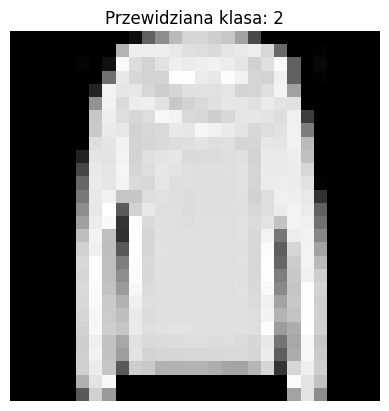

Predykcja: 2
Prawidłowa klasa: 2
INFO:tensorflow:Assets written to: fashion_mnist_model.keras 0.9036666750907898\assets


INFO:tensorflow:Assets written to: fashion_mnist_model.keras 0.9036666750907898\assets


In [7]:
prediction = predict_image(X_test[0])
print("Predykcja:", prediction)
print("Prawidłowa klasa:", y_test[0])

f_mnist_model.save(f"fashion_mnist_model.keras {test_accuracy}")

Krok 3 - augumentacja

In [8]:
X_learning, X_val, y_learning, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train,
)

import albumentations as A

augmentation = A.Compose([
    A.Affine(
        scale=(0.95, 1.05),
        translate_percent=(-0.05, 0.05),
        rotate=(-8, 8),
        p=1.0,
    ),
    A.HorizontalFlip(p=0.5),
])
augmented_images = []

for image in X_learning:
    result = augmentation(image=image)
    augmented_images.append(result["image"])

augmented_images = np.array(
    augmented_images,
    dtype=np.float32,
)
X_learning_aug = np.concatenate([
    X_learning,
    augmented_images,
])

y_learning_aug = np.concatenate([
    y_learning,
    y_learning,
])

print("Przed augmentacją:", X_learning.shape)
print("Po augmentacji:", X_learning_aug.shape)

Przed augmentacją: (48600, 28, 28)
Po augmentacji: (97200, 28, 28)


In [9]:
f_mnist_model_aug = tf.keras.models.clone_model(
    f_mnist_model
)

f_mnist_model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

train_stats_aug = f_mnist_model_aug.fit(
    X_learning_aug,
    y_learning_aug,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        lr_scheduler,
        early_stopping,
    ],
    verbose=1,
)

Epoch 1/100
3038/3038 [==============================] - 29s 10ms/step - loss: 0.6173 - accuracy: 0.7716 - val_loss: 0.3910 - val_accuracy: 0.8572 - lr: 0.0010
Epoch 2/100
3038/3038 [==============================] - 28s 9ms/step - loss: 0.4835 - accuracy: 0.8212 - val_loss: 0.3572 - val_accuracy: 0.8681 - lr: 0.0010
Epoch 3/100
3038/3038 [==============================] - 26s 9ms/step - loss: 0.4428 - accuracy: 0.8364 - val_loss: 0.3485 - val_accuracy: 0.8776 - lr: 0.0010
Epoch 4/100
3038/3038 [==============================] - 28s 9ms/step - loss: 0.4198 - accuracy: 0.8449 - val_loss: 0.3514 - val_accuracy: 0.8806 - lr: 0.0010
Epoch 5/100
3038/3038 [==============================] - 28s 9ms/step - loss: 0.4037 - accuracy: 0.8501 - val_loss: 0.3348 - val_accuracy: 0.8811 - lr: 0.0010
Epoch 6/100
3038/3038 [==============================] - 28s 9ms/step - loss: 0.3889 - accuracy: 0.8559 - val_loss: 0.3144 - val_accuracy: 0.8924 - lr: 0.0010
Epoch 7/100
3038/3038 [======================

In [10]:
test_loss_aug, test_accuracy_aug = (
    f_mnist_model_aug.evaluate(
        X_test,
        y_test,
    )
)

print("Wynik bez augmentacji:", test_accuracy)
print("Wynik z augmentacją:", test_accuracy_aug)

188/188 [==============================] - 1s 3ms/step - loss: 0.3136 - accuracy: 0.9030
Wynik bez augmentacji: 0.9036666750907898
Wynik z augmentacją: 0.902999997138977


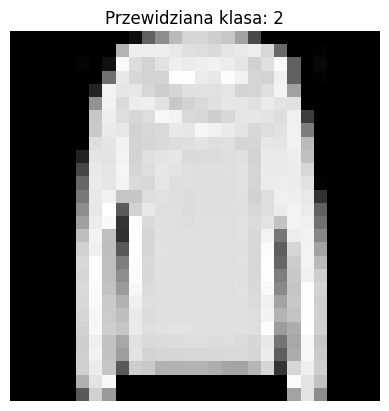

Predykcja: 2
Prawidłowa klasa: 2


In [11]:
prediction = predict_image(X_test[0])
print("Predykcja:", prediction)
print("Prawidłowa klasa:", y_test[0])

In [12]:
f_mnist_model_aug.save(f"fashion_mnist_model.keras {test_accuracy_aug}")

INFO:tensorflow:Assets written to: fashion_mnist_model.keras 0.902999997138977\assets


INFO:tensorflow:Assets written to: fashion_mnist_model.keras 0.902999997138977\assets


Wynik z augumentacją nie poprawił się. Augumentacja utrudnia trening